<!-- # Lightweight Grid Calibration Notebook

This notebook compares synthetic and real grids using the exported CSV metrics only.

It keeps status-stratified diagnostics at the top as a check, but uses the full synthetic export for the main representativeness comparison. Normalized Wasserstein distance is the primary score, and feeder count is shown together with buildings per feeder. -->

In [1]:
import importlib
import sys
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = (project_root / ".." / "..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

scoring = importlib.import_module("validations.grid_comparison.scoring")
scoring = importlib.reload(scoring)
comparison_notebook = importlib.import_module("validations.grid_comparison.comparison_notebook")
comparison_notebook = importlib.reload(comparison_notebook)

DEFAULT_LABELS = comparison_notebook.DEFAULT_LABELS
DEFAULT_METRICS = comparison_notebook.DEFAULT_METRICS
default_metric_filenames = comparison_notebook.default_metric_filenames
selected_metric_filenames = comparison_notebook.selected_metric_filenames
load_and_render_overview = comparison_notebook.load_and_render_overview
plot_boxplot_overview = comparison_notebook.plot_boxplot_overview
plot_metric_kde_diagonal = comparison_notebook.plot_metric_kde_diagonal
plot_scenario_kde_diagonal = comparison_notebook.plot_scenario_kde_diagonal
show_cable_type_comparison = comparison_notebook.show_cable_type_comparison
show_distribution_selector = comparison_notebook.show_distribution_selector
show_wasserstein_summary = comparison_notebook.show_wasserstein_summary

METRICS_DIR = project_root / "validations" / "metrics"
# Set explicit CSV filenames here, or leave as None to use the automatic fallback.
SYNTHETIC_METRICS_FILE = None  # None uses default_metric_filenames() to find the most recent synthetic metrics file
REAL_METRICS_FILE = "real_grid_metrics_swf_split_station_hybrid_v2.csv"
SYNTHETIC_METRICS_FILE, REAL_METRICS_FILE = selected_metric_filenames(
    SYNTHETIC_METRICS_FILE,
    REAL_METRICS_FILE,
    METRICS_DIR,
)
METRICS = list(DEFAULT_METRICS)
LABELS = dict(DEFAULT_LABELS)
PALETTE = {"Synthetic": "steelblue", "Real": "crimson"}
PLZ = 91301
REAL_GRID_DIR = None  # None uses GRID_DATA_PATH and GRID_SPLIT_SUBDIR from the project .env

In [2]:
notebook_data = load_and_render_overview(
    metrics_dir=METRICS_DIR,
    metrics=METRICS,
    labels=LABELS,
    synthetic_metrics_filename=SYNTHETIC_METRICS_FILE,
    real_metrics_filename=REAL_METRICS_FILE,
)

### Data Inputs

,source,path,rows
0,Synthetic,/home/breveron/git/github/pylovo/validations/m...,98
1,Real,/home/breveron/git/github/pylovo/validations/m...,112


### Status-Stratified Diagnostics

,power_flow_status,count
0,converged,47
1,voltage_violation,51


,power_flow_status,synthetic_n,real_n,mean_normalized_wasserstein,median_normalized_wasserstein,worst_metric,worst_normalized_wasserstein
0,converged,47,112,0.2973,0.2794,max_trafo_distance,0.3826
1,voltage_violation,51,112,0.5561,0.5980,graph_length,0.6967


### Primary Wasserstein Score

,metric,synthetic_n,real_n,wasserstein_distance,normalized_wasserstein,quality
0,transformer_mva,98,112,0.0123,0.0537,excellent
1,max_trafo_distance,98,112,0.0747,0.2009,good
2,feeder_lines,98,112,1.3278,0.2213,good
3,graph_resistance,98,112,0.0680,0.2390,good
4,avg_trafo_distance,98,112,0.0486,0.2486,good
5,graph_length,98,112,0.3559,0.2725,acceptable


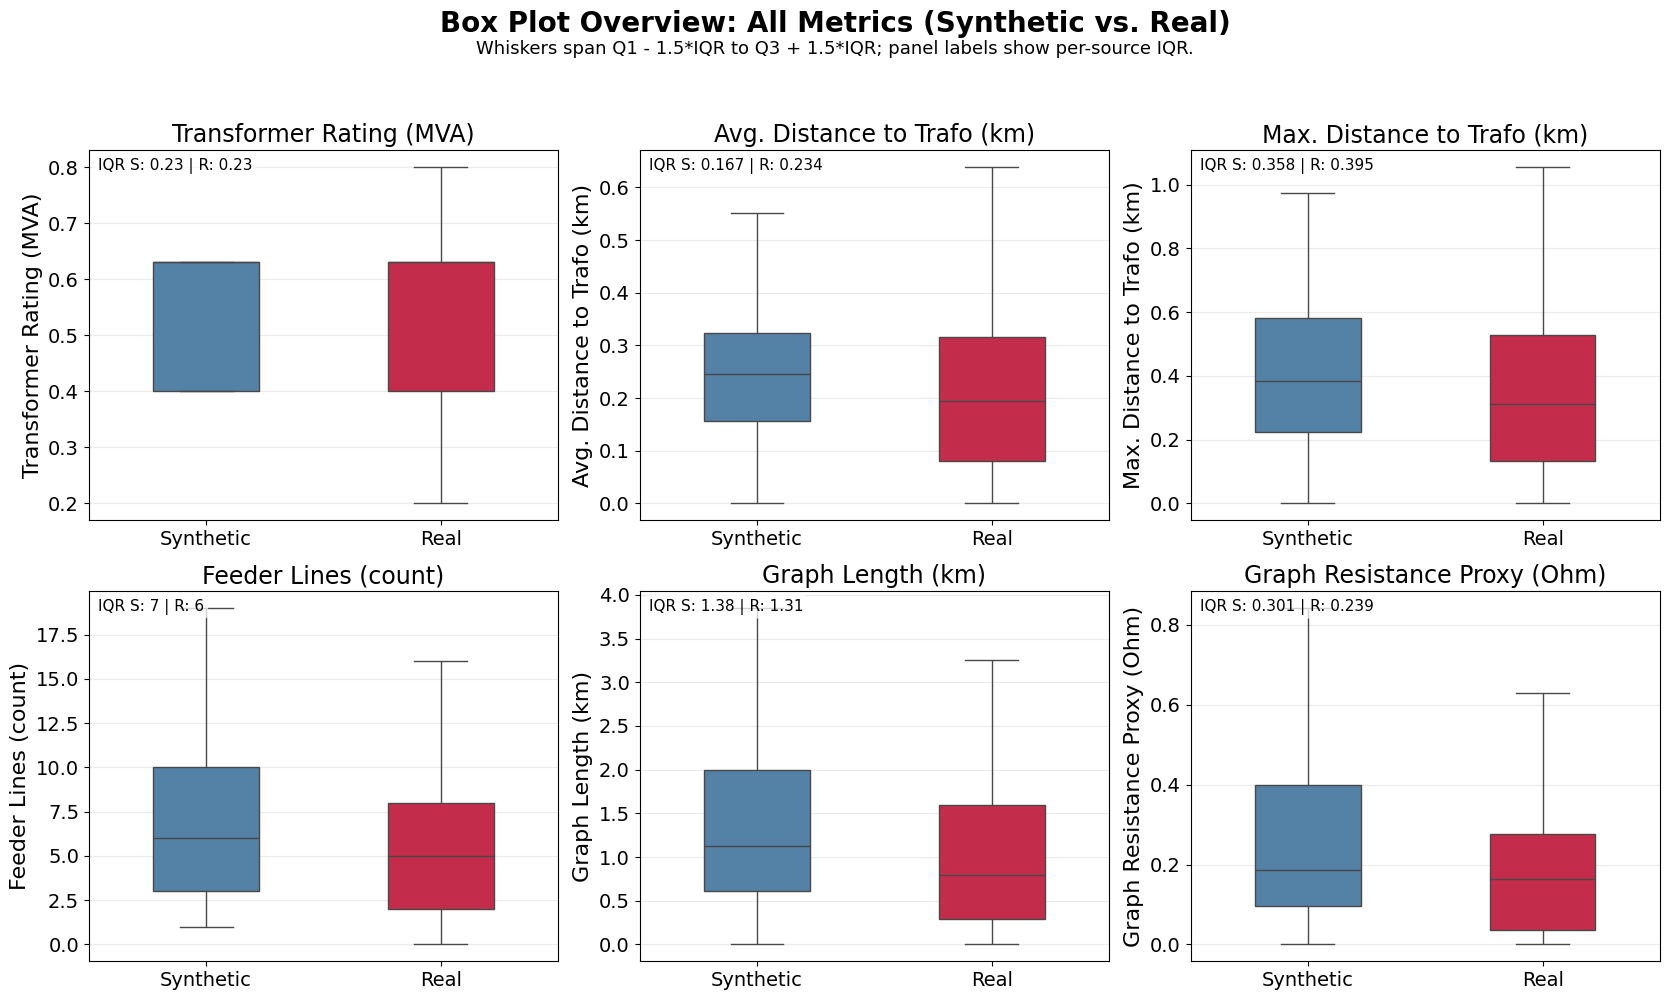

In [3]:
_ = plot_boxplot_overview(
    notebook_data.df_all,
    notebook_data.metrics,
    labels=notebook_data.labels,
    palette=PALETTE,
    title="Box Plot Overview: All Metrics (Synthetic vs. Real)",
    save_path="output/box.pdf", # e.g. METRICS_DIR / "boxplot_overview.svg" or .pdf
)

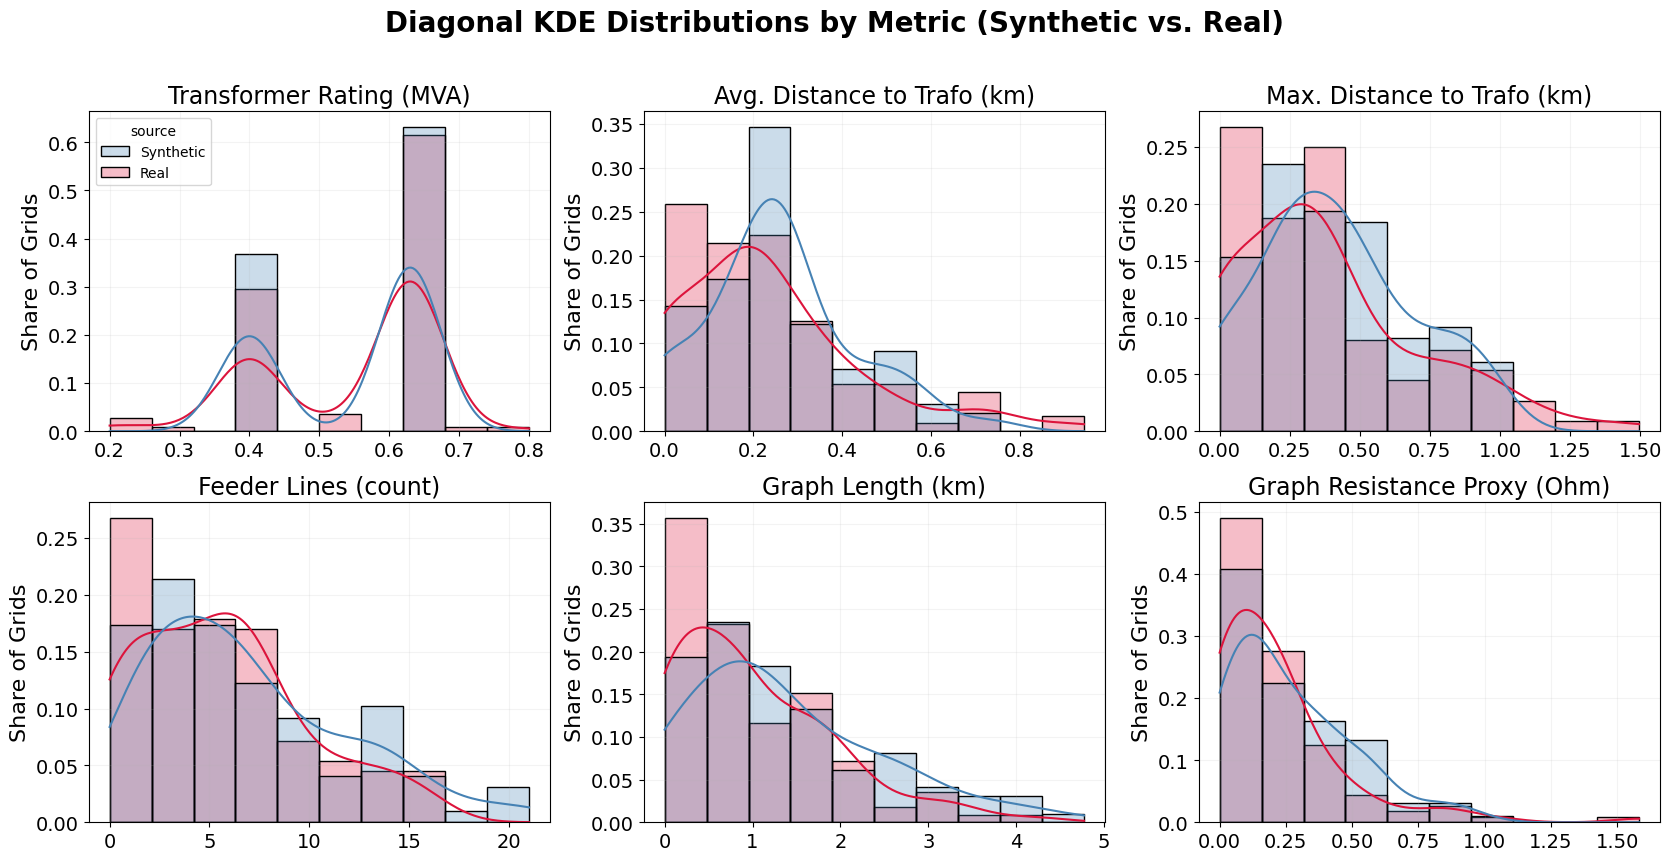

In [7]:
_ = plot_metric_kde_diagonal(
    notebook_data.df_all,
    notebook_data.metrics,
    labels=notebook_data.labels,
    palette=PALETTE,
    show_hist_bars=True,
    bins=10,
    n_cols=3,
    title="Diagonal KDE Distributions by Metric (Synthetic vs. Real)",
    upper_percentile=KDE_UPPER_PERCENTILE if "KDE_UPPER_PERCENTILE" in globals() else None,
    clip_nonnegative=True,
    save_path="output/metric_kde_diagonal.pdf",  # e.g. METRICS_DIR / "metric_kde_diagonal.svg" or .pdf
)

<!-- ### Scenario KDE Comparison

KDE-only comparison of all four synthetic scenario distributions against one real reference distribution. -->


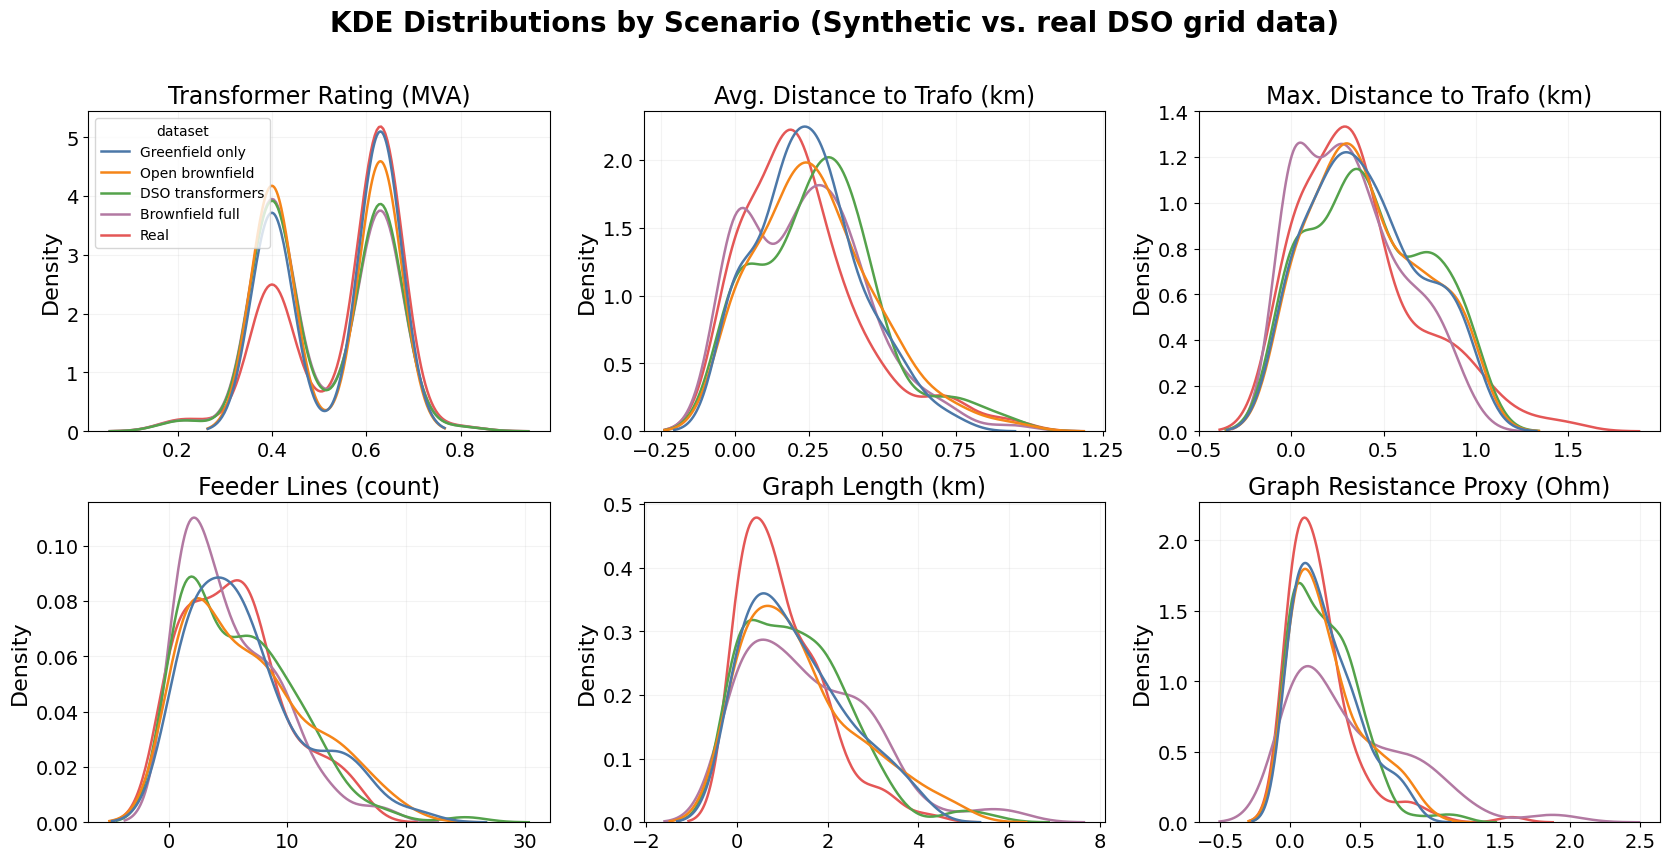

In [8]:
SCENARIO_METRIC_FILES = {
    "Greenfield only": "synthetic_grid_metrics_s1dvgf.csv",
    "Open brownfield": "synthetic_grid_metrics_s2dvop.csv",
    "DSO transformers": "synthetic_grid_metrics_s3dsoimp.csv",
    "Brownfield full": "synthetic_grid_metrics_s4ha150.csv",
}

SCENARIO_PALETTE = {
    "Greenfield only": "#4C78A8",
    "Open brownfield": "#F58518",
    "DSO transformers": "#54A24B",
    "Brownfield full": "#B279A2",
    "Real": "#E45756",
}

_ = plot_scenario_kde_diagonal(
    SCENARIO_METRIC_FILES,
    METRICS,
    metrics_dir=METRICS_DIR,
    real_metrics_filename=REAL_METRICS_FILE,
    labels=LABELS,
    palette=SCENARIO_PALETTE,
    n_cols=3,
    title="KDE Distributions by Scenario (Synthetic vs. real DSO grid data)",
    upper_percentile=1,
    clip_nonnegative=False,
)